## Assembling a Feature Engineering Pipeline with Hyperparameter Optimization

In this notebook, I will assemble a feature engineering pipeline followed by a Gradient Boosting Classifier. I will search for the best hyperparameters both for the machine learning model and the feature engineering steps using Grid Search.

In summary, we will:

- set up a series of feature engineering steps using [Feature-engine](https://feature-engine.readthedocs.io/en/latest/index.html)
- train a Gradient Boosting Classifier
- train the pipeline with cross-validation, looking over different feature-engineering and model hyperparameters

For more details on feature engineering and hyperparameter optimization feel free to check my [online courses](https://www.trainindata.com/).

In [6]:
# Let's install Feature-engine
# an open-source Python library for feature engineering
# it allows us to select which features we want to transform
# straight-away from within each transformer

# https://feature-engine.readthedocs.io/en/latest/index.html

!pip install feature-engine


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Luis Mendez\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for the model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

# for feature engineering
from feature_engine import imputation as mdi
from feature_engine import encoding as ce

## Load the data

In [8]:
data = pd.read_csv("titanic/train.csv")

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# the aim of this notebook is to show how to optimize hyperparameters of an
# entire machine learning pipeline.

# So I will take a shortcut and remove some features to make things simpler

cols = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
    'Embarked', 'Survived'
]

data = data[cols]

data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,3,male,22.0,1,0,7.2500,NaN,S,0
1,1,female,38.0,1,0,71.2833,C85,C,1
2,3,female,26.0,0,0,7.9250,NaN,S,1
3,1,female,35.0,1,0,53.1000,C123,S,1
4,3,male,35.0,0,0,8.0500,NaN,S,0


In [10]:
# Cabin: extract numerical and categorical part and delete original variable

data['cabin_num'] = data['Cabin'].str.extract('(\d+)') # captures numerical part
data['cabin_num'] = data['cabin_num'].astype('float')
data['cabin_cat'] = data['Cabin'].str[0] # captures the first letter

data.drop(['Cabin'], axis=1, inplace=True)

data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,cabin_num,cabin_cat
0,3,male,22.0,1,0,7.2500,S,0,NaN,NaN
1,1,female,38.0,1,0,71.2833,C,1,85.0,C
2,3,female,26.0,0,0,7.9250,S,1,NaN,NaN
3,1,female,35.0,1,0,53.1000,S,1,123.0,C
4,3,male,35.0,0,0,8.0500,S,0,NaN,NaN


In [11]:
# make list of variables types
# we need these lists to indicate Feature-engine which variables it should modify

# numerical: discrete
discrete = [
    var for var in data.columns if data[var].dtype != 'O' and var != 'Survived'
    and data[var].nunique() < 10
]

# numerical: continuous
continuous = [
    var for var in data.columns
    if data[var].dtype != 'O' and var != 'Survived' and var not in discrete
]

# categorical
categorical = [var for var in data.columns if data[var].dtype == 'O']

print('There are {} discrete variables'.format(len(discrete)))
print('There are {} continuous variables'.format(len(continuous)))
print('There are {} categorical variables'.format(len(categorical)))

There are 6 discrete variables
There are 3 continuous variables
There are 0 categorical variables


In [12]:
# discrete variables

discrete

['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'cabin_cat']

In [13]:
# continuous variables

continuous

['Age', 'Fare', 'cabin_num']

In [14]:
# categorical variables

categorical

[]

In [15]:
# separate into training and testing set

X_train, X_test, y_train, y_test = train_test_split(
    data.drop('Survived', axis=1),  # predictors
    data['Survived'],  # target
    test_size=0.1,  # percentage of obs in test set
    random_state=0)  # seed to ensure reproducibility

X_train.shape, X_test.shape

((801, 9), (90, 9))

### Set up the pipeline

We assemble a pipeline with default or some hyperparameters for each step. But we will modify this during the hyperparameter search later on.

In [16]:
titanic_pipe = Pipeline([

    # missing data imputation - we replace na in numerical variables
    # with an arbitrary value. 
    ('imputer_num',
     mdi.ArbitraryNumberImputer(arbitrary_number=-1,
                                variables=['Age', 'Fare', 'cabin_num'])),
    
    # for categorical variables, we can either replace na with the string
    # missing or with the most frequent category
    ('imputer_cat',
     mdi.CategoricalImputer(variables=['Embarked', 'cabin_cat'])),

    # categorical encoding - we will group rare categories into 1
    ('encoder_rare_label', ce.RareLabelEncoder(
        tol=0.01,
        n_categories=2,
        variables=['Embarked', 'cabin_cat'],
    )),
    
    # we replace category names by numbers
    ('categorical_encoder', ce.OrdinalEncoder(
        encoding_method='ordered',
        variables=['cabin_cat', 'Sex', 'Embarked'],
    )),

    # Gradient Boosted machine
    ('gbm', GradientBoostingClassifier(random_state=0))
])

## Grid Search with Cross-validation

For hyperparameter search we need:

- the machine learning pipeline that we want to optimize (in the previous cell)
- the hyperparamter space that we want to sample (next cell)
- a metric to optimize
- an algorithm to sample the hyperparameters (Grid Search in this case)

Let's do that.

In [17]:
# now we create the hyperparameter space that we want to sample
# that is, the hyperparameter values that we want to test.

# to perform Grid search, we need to specifically provide the hyperparameter
# values that we want to test

# to opimize hyperparameters within a pipeline, we assemble the space
# as follows:

param_grid = {
    # try different feature engineering parameters:
    
    # test different parameters to replace na with numbers
    'imputer_num__arbitrary_number': [-1, 99],
    
    # test imputation with frequent category or string missing
    'imputer_cat__imputation_method': ['missing','frequent'],
    
    # test different thresholds to group rare labels
    'encoder_rare_label__tol': [0.1, 0.2],
    
    # test 2 different encoding strategies
    'categorical_encoder__encoding_method': ['ordered', 'arbitrary'],
    
    # try different gradient boosted tree model paramenters
    'gbm__max_depth': [None, 1, 3],
    'gbm__n_estimators': [10, 20, 50, 100, 200]
}

# (note how we call the step name in the pipeline followed by __
# followed by the name of the hyperparameter that we want to modify)

# for more details on the Feature-engine transformers hyperparameters, visit
# Feature-engine documentation

In [18]:
# now we set up the grid search with cross-validation

# we are optimizing over few hyperparameters altogether, so 
# a GridSearch should be more than enough

grid_search = GridSearchCV(
    titanic_pipe, # the pipeline
    param_grid, # the hyperparameter space
    cv=3, # the cross-validation
    scoring='roc_auc', # the metric to optimize
)

# for more details in the grid parameters visit:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [19]:
# and now we train over all the possible combinations of the parameters
# specified above
grid_search.fit(X_train, y_train)

# and we print the best score over the train set
print(("best roc-auc from grid search: %.3f"
       % grid_search.score(X_train, y_train)))

best roc-auc from grid search: 0.972


In [20]:
# and finally let's check the performance over the test set

print(("best linear regression from grid search: %.3f"
       % grid_search.score(X_test, y_test)))

best linear regression from grid search: 0.886


In [21]:
# we can find the best pipeline with its parameters like this

grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer_num', ...), ('imputer_cat', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,arbitrary_number,99
,variables,"['Age', 'Fare', ...]"
,imputer_dict,None
,imputation_method,'missing'
,fill_value,'Missing'
,variables,"['Embarked', 'cabin_cat']"
,return_object,False


In [22]:
# and find the best fit parameters like this

grid_search.best_params_

{'categorical_encoder__encoding_method': 'ordered',
 'encoder_rare_label__tol': 0.1,
 'gbm__max_depth': 3,
 'gbm__n_estimators': 200,
 'imputer_cat__imputation_method': 'missing',
 'imputer_num__arbitrary_number': 99}

In [23]:
# we also find the data for all models evaluated

results = pd.DataFrame(grid_search.cv_results_)

print(results.shape)

results.head()

(240, 17)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_categorical_encoder__encoding_method,param_encoder_rare_label__tol,param_gbm__max_depth,param_gbm__n_estimators,param_imputer_cat__imputation_method,param_imputer_num__arbitrary_number,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.095271,0.022487,0.015591,0.003540,ordered,0.1,None,10,missing,-1,{'categorical_encoder__encoding_method': 'orde...,0.746541,0.815072,0.785399,0.782337,0.028062,204
1,0.075852,0.003351,0.013084,0.000666,ordered,0.1,None,10,missing,99,{'categorical_encoder__encoding_method': 'orde...,0.783013,0.820559,0.774842,0.792805,0.019907,185
2,0.080362,0.003127,0.013898,0.001239,ordered,0.1,None,10,frequent,-1,{'categorical_encoder__encoding_method': 'orde...,0.745348,0.817339,0.768639,0.777108,0.029994,213
3,0.080128,0.005201,0.012858,0.000479,ordered,0.1,None,10,frequent,99,{'categorical_encoder__encoding_method': 'orde...,0.783699,0.827598,0.767506,0.792934,0.025387,184
4,0.124626,0.004954,0.012013,0.000408,ordered,0.1,None,20,missing,-1,{'categorical_encoder__encoding_method': 'orde...,0.736133,0.791035,0.783878,0.770349,0.024370,234


Text(0.5, 0, 'Hyperparameter combinations')

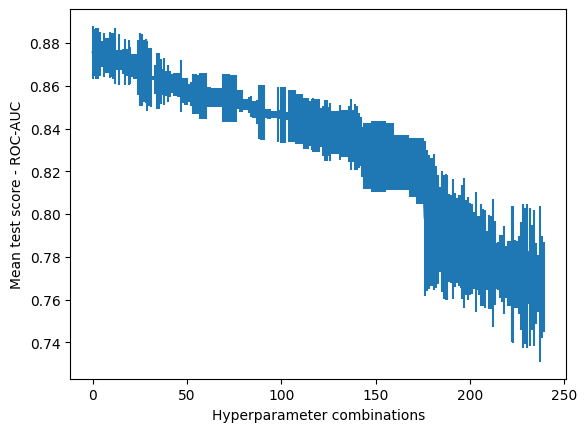

In [24]:
# we can order the different models based on their performance

results.sort_values(by='mean_test_score', ascending=False, inplace=True)

results.reset_index(drop=True, inplace=True)


# plot model performance and the generalization error

results['mean_test_score'].plot(yerr=[results['std_test_score'], results['std_test_score']], subplots=True)

plt.ylabel('Mean test score - ROC-AUC')
plt.xlabel('Hyperparameter combinations')

<Axes: >

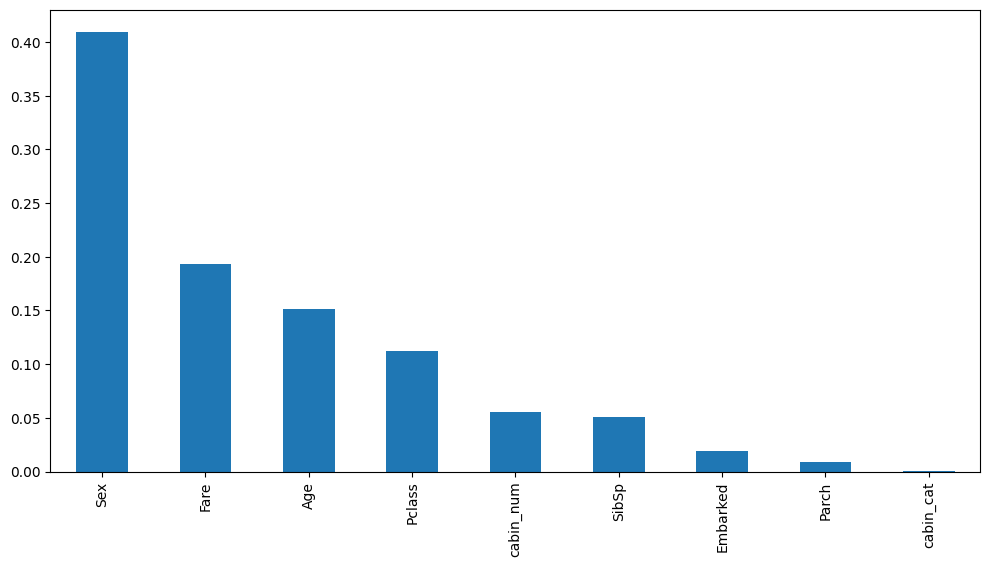

In [25]:
# and to wrap up:
# let's explore the importance of the features

importance = pd.Series(grid_search.best_estimator_['gbm'].feature_importances_)
importance.index = data.drop('Survived', axis=1).columns
importance.sort_values(inplace=True, ascending=False)
importance.plot.bar(figsize=(12,6))

If you liked this notebook and would like to know more about feature engineering and hyperparameter optimization feel free to check my [online courses](https://www.trainindata.com/).